# Get expression matrix

In [4]:
import pandas as pd

proteome = pd.read_csv("../data/raw/proteomic/proteome_imputed.tsv",sep="\t")

proteome = proteome.set_index("gene")
proteome = proteome.drop(columns=["refseq_id"])

proteome.describe()

,C3L-00104,C3L-00365,C3L-00674,C3L-00677,C3L-01040,C3L-01043,C3L-01045,C3L-01046,C3L-01048,C3L-01049,...,PT-NPJ7,PT-P44H,PT-Q2AG,PT-QVJO,PT-R55F,PT-RN5K,PT-RU72,PT-UTHO,PT-WVLH,PT-Y8DK
count,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,...,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000
mean,0.011871,-0.042128,0.065560,0.043825,0.011158,0.007011,-0.019791,0.014513,-0.030062,-0.014379,...,0.212444,0.186822,0.213447,0.214324,0.186166,0.183888,0.180634,0.215678,0.198933,0.212333
std,0.398464,0.519172,0.484682,0.491390,0.459679,0.540076,0.636358,0.625826,0.539239,0.505644,...,1.124159,1.047652,1.147825,1.100425,1.032947,1.028260,1.032960,1.138039,1.077398,0.983133
min,-2.657711,-4.351911,-4.042548,-2.704767,-2.972341,-2.771862,-5.557296,-2.427878,-6.637013,-4.134884,...,-4.250483,-3.988596,-3.850057,-3.841200,-4.318241,-4.412635,-3.958472,-4.798275,-4.617543,-3.548880
25%,-0.214137,-0.275860,-0.206297,-0.236896,-0.236898,-0.261292,-0.325196,-0.332010,-0.306827,-0.285646,...,-0.553309,-0.510583,-0.566653,-0.555937,-0.494017,-0.512372,-0.512621,-0.559916,-0.526732,-0.448280
50%,-0.009111,0.001024,0.017964,0.011271,-0.006335,0.010394,0.012342,-0.015217,-0.001970,-0.011199,...,-0.010831,-0.002648,-0.010050,0.013092,-0.002171,0.003449,-0.028826,0.008523,-0.000431,0.013485
75%,0.206262,0.246491,0.280381,0.281016,0.237255,0.237951,0.309377,0.319180,0.300801,0.230133,...,0.777137,0.719674,0.803101,0.800842,0.725325,0.720828,0.690007,0.815056,0.771391,0.721034
max,3.520582,2.516254,3.133515,4.343769,3.433517,3.619684,5.607979,4.514111,3.923987,3.750830,...,5.199594,4.477295,4.788296,4.570630,4.175174,5.194838,4.744290,5.068041,4.562353,4.036980


# Get metadata

In [5]:
clin = pd.read_csv("../data/raw/proteomic/all_subtypes.v5.1.tsv",sep="\t")
clin
tumor_id = clin[clin["sample_type"] == "tumor"]["case"].tolist()
normal_id = clin[clin["sample_type"] == "GTEx normal"]["case"].tolist()

meta = pd.read_csv("../data/raw/proteomic/all_subtypes.v5.1.tsv",sep = '\t')
meta['rna_wang_cancer_cell_2017'].unique()
proneural_id = meta[meta['rna_wang_cancer_cell_2017'] == 'Proneural']['case'].tolist()
mesenchymal_id = meta[meta['rna_wang_cancer_cell_2017'] == 'Mesenchymal']['case'].tolist()
classical_id = meta[meta['rna_wang_cancer_cell_2017'] == 'Classical']['case'].tolist()
idh_id = meta[meta['rna_wang_cancer_cell_2017'] == 'IDH mutant']['case'].tolist()
normal2_id = meta[meta["sample_type"] == "GTEx normal"]["case"].tolist()
normal2_id.pop(2)

'PT-Q2AG'

# Split into tumor and normal expression matrix

In [6]:
gbm_expr = proteome[tumor_id]
proneural_expr = proteome[proneural_id]
mesenchymal_expr = proteome[mesenchymal_id]
classical_expr = proteome[classical_id]
idh_expr = proteome[idh_id]
control_expr = proteome[normal_id]
control_expr

,PT-NPJ7,PT-P44H,PT-Q2AG,PT-QVJO,PT-R55F,PT-RN5K,PT-RU72,PT-UTHO,PT-WVLH,PT-Y8DK
gene,,,,,,,,,,
A1BG,-1.717510,-1.357500,-1.528595,-1.539841,-1.789458,-1.624156,-1.452245,-1.902994,-2.003926,-1.590282
A2M,-1.064325,-0.806817,-1.511272,-1.247939,-1.478376,-1.163916,-1.147384,-1.162469,-1.605927,-1.227305
AAAS,-0.306516,-0.580316,-0.710189,-0.672322,-0.764798,-0.570896,-0.373231,-0.411892,-0.694845,-0.487413
AACS,0.436075,0.556105,0.888602,0.916637,0.857309,0.608478,0.584371,0.534934,0.817702,0.866017
AADAT,1.316010,1.429100,1.337539,1.630508,1.157699,0.756814,1.040895,1.230606,0.644152,1.033949
...,...,...,...,...,...,...,...,...,...,...
ZXDC,0.164100,0.517515,-0.076385,-1.330917,0.080553,-0.007176,-0.073908,1.278683,-0.233022,-0.250798
ZYG11B,0.767921,0.379683,0.791386,0.667393,0.563370,0.609314,0.637394,0.616285,0.732273,0.623839
ZYX,-1.128100,-1.087567,-0.667928,-1.172195,-0.973314,-1.293464,-0.795886,-0.734952,-1.158899,-0.892930


In [7]:
import sys
sys.path.append("../src")

import diff
import importlib

importlib.reload(diff)

print(dir(diff))

['PCA', 'StandardScaler', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'differential_expression', 'multipletests', 'np', 'pca_plot', 'pd', 'plt', 'ttest_ind', 'volcano_plot']


In [21]:
results = diff.differential_expression(gbm_expr,control_expr)
results.to_csv("../data/interim/de_proteome.csv")
results.to_csv("../data/interim/CPTAC_pro_diff.csv")

In [10]:
results

,log2FC,pvalue,adjustedpvalue,-log(adjustedp),category
gene,,,,,
A1BG,1.751663,1.740332e-19,1.649829e-18,17.782561,Up
A2M,1.446368,2.631714e-14,1.480730e-13,12.829524,Up
AAAS,0.603250,5.753307e-08,1.502036e-07,6.823320,Not Significant
AACS,-0.747064,8.155613e-09,2.376589e-08,7.624046,Not Significant
AADAT,-1.181237,7.377722e-08,1.893361e-07,6.722767,Down
...,...,...,...,...,...
ZXDC,-0.051378,8.127155e-01,8.287182e-01,0.081593,Not Significant
ZYG11B,-0.642655,5.650706e-12,2.446680e-11,10.611423,Not Significant
ZYX,1.046176,1.121758e-11,4.672422e-11,10.330458,Up


# ENTIRE DATASET

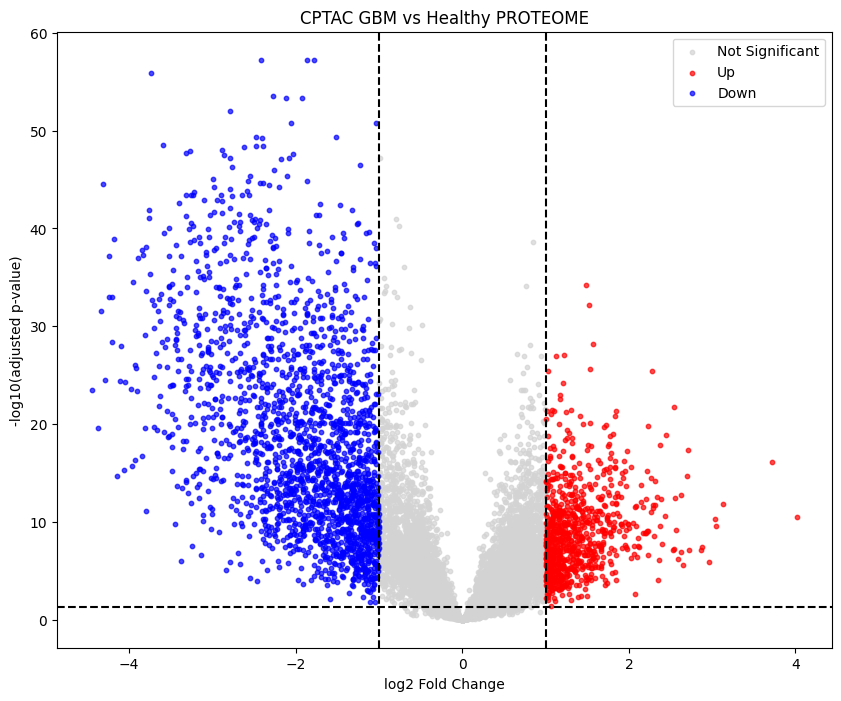

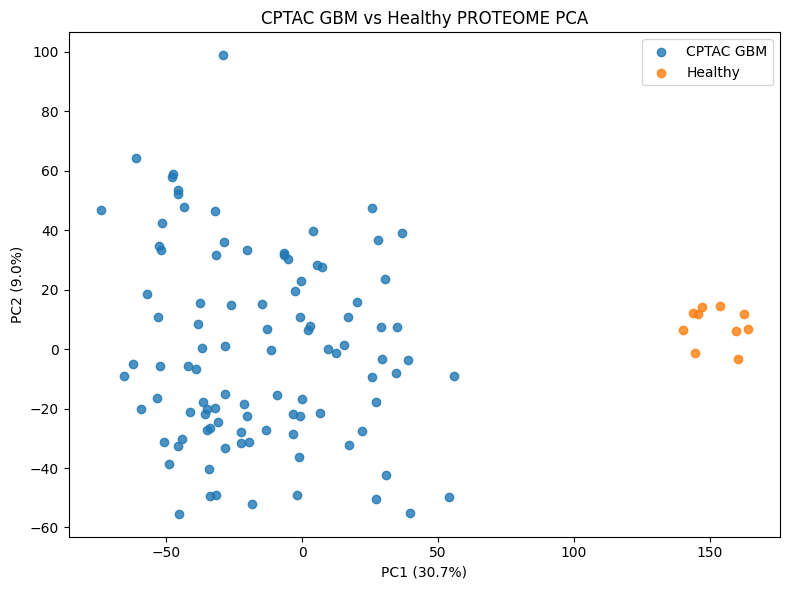

(            PC1        PC2      Group
 0      2.085065   6.274493  CPTAC GBM
 1    -38.524332   8.430314  CPTAC GBM
 2     -3.350541 -21.780350  CPTAC GBM
 3      9.475952  -0.025187  CPTAC GBM
 4     -2.788888  19.550523  CPTAC GBM
 ..          ...        ...        ...
 104  144.612034  -1.316105    Healthy
 105  143.915595  12.054927    Healthy
 106  163.944194   6.871756    Healthy
 107  153.672228  14.488014    Healthy
 108  140.259531   6.516680    Healthy
 
 [109 rows x 3 columns],
 PCA(n_components=2))

In [14]:
diff.volcano_plot(results,'CPTAC GBM vs Healthy PROTEOME')
diff.pca_plot(gbm_expr,control_expr,'CPTAC GBM','Healthy','CPTAC GBM vs Healthy PROTEOME PCA')

# Proneural

In [16]:
pro = diff.differential_expression(proneural_expr,control_expr)
pro.to_csv('../data/interim/proneural_pro_diff.csv')

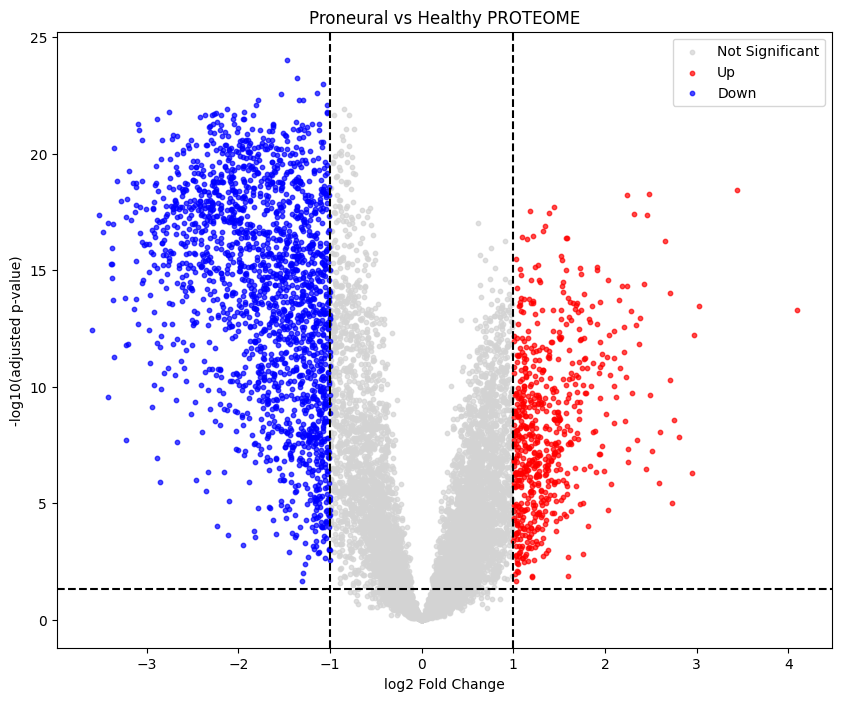

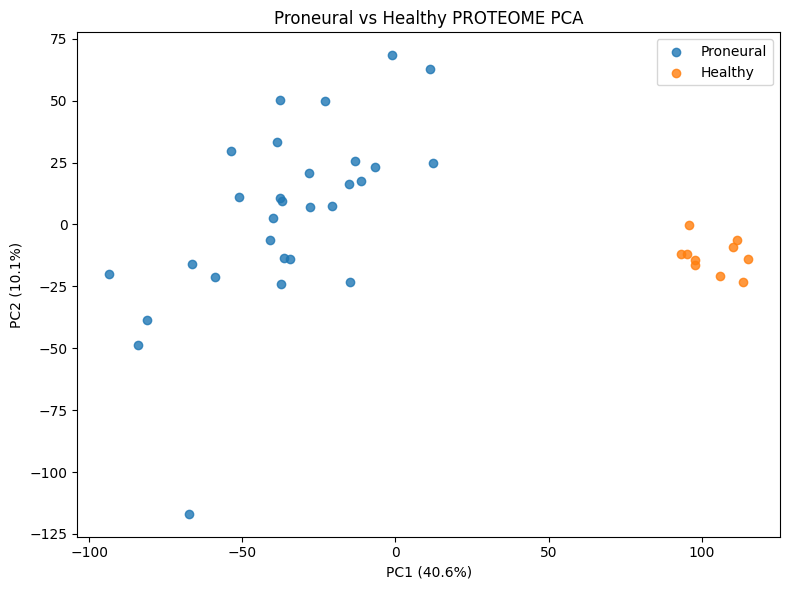

(           PC1         PC2      Group
 0   -37.653413   10.786806  Proneural
 1   -28.062797    6.957186  Proneural
 2   -53.540273   29.836924  Proneural
 3   -67.493089 -116.882601  Proneural
 4    -6.724228   23.158056  Proneural
 5    -1.218158   68.346972  Proneural
 6   -51.033450   11.266332  Proneural
 7   -83.947401  -48.787548  Proneural
 8   -37.447259  -24.136700  Proneural
 9   -20.649660    7.522543  Proneural
 10  -66.571232  -15.908085  Proneural
 11  -38.524608   33.324624  Proneural
 12  -93.448986  -20.030650  Proneural
 13  -59.018536  -21.221215  Proneural
 14  -36.989904    9.389555  Proneural
 15  -36.409529  -13.401888  Proneural
 16  -11.409994   17.533591  Proneural
 17  -37.830292   50.436932  Proneural
 18  -40.130734    2.470994  Proneural
 19  -28.260567   20.761306  Proneural
 20  -14.832306  -23.253757  Proneural
 21  -41.062708   -6.265722  Proneural
 22  -34.411571  -13.919930  Proneural
 23  -23.104595   49.965526  Proneural
 24  -15.248034   16.2794

In [17]:
diff.volcano_plot(pro,'Proneural vs Healthy PROTEOME')
diff.pca_plot(proneural_expr,control_expr,'Proneural','Healthy','Proneural vs Healthy PROTEOME PCA')

# Mesenchymal

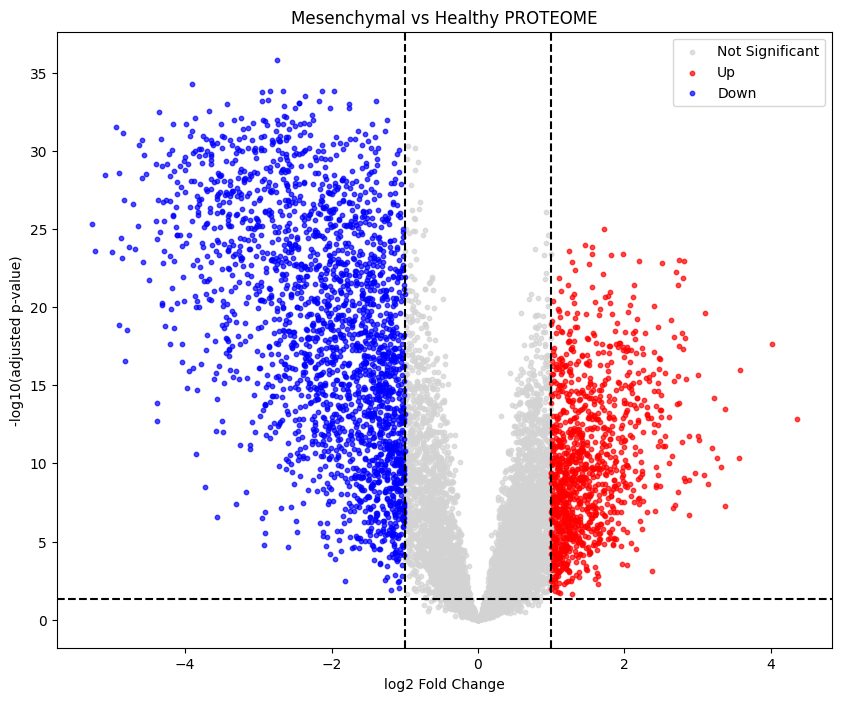

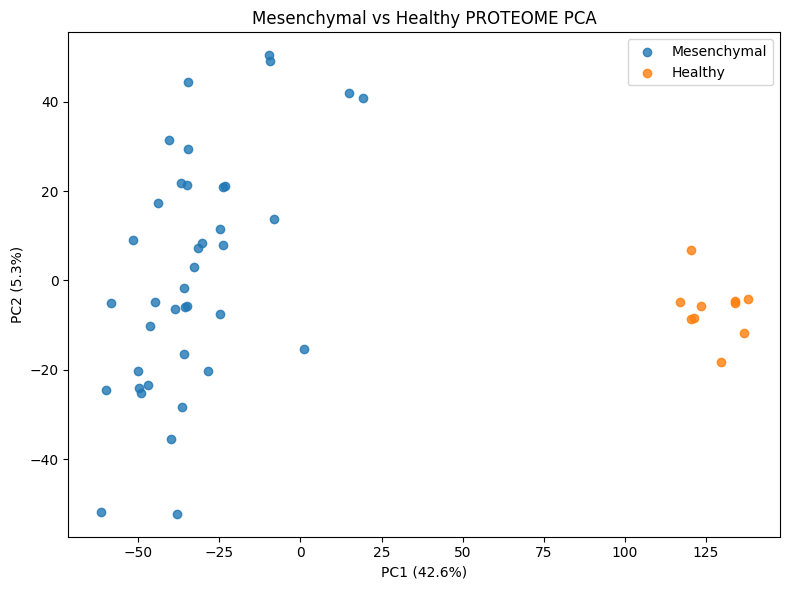

(           PC1        PC2        Group
 0    -9.246023  49.020745  Mesenchymal
 1   -51.584940   9.023018  Mesenchymal
 2   -47.111233 -23.397232  Mesenchymal
 3   -46.412045 -10.163959  Mesenchymal
 4   -50.115774 -20.258292  Mesenchymal
 5   -49.127544 -25.328409  Mesenchymal
 6   -23.337174  21.166569  Mesenchymal
 7     1.100499 -15.292472  Mesenchymal
 8    -9.624855  50.401756  Mesenchymal
 9    19.333452  40.876997  Mesenchymal
 10   -8.253864  13.684095  Mesenchymal
 11  -44.969870  -4.810437  Mesenchymal
 12  -23.783996   7.930195  Mesenchymal
 13  -28.468744 -20.346568  Mesenchymal
 14  -23.797491  20.920748  Mesenchymal
 15  -35.519981  -6.027777  Mesenchymal
 16  -40.381190  31.369430  Mesenchymal
 17  -34.946404  -5.631181  Mesenchymal
 18  -24.655105  11.511840  Mesenchymal
 19  -49.789529 -24.155489  Mesenchymal
 20  -39.818842 -35.632672  Mesenchymal
 21  -36.673559  21.813724  Mesenchymal
 22  -34.585851  44.384197  Mesenchymal
 23  -43.945466  17.433361  Mesenchymal


In [18]:
mes = diff.differential_expression(mesenchymal_expr,control_expr)
mes.to_csv('../data/interim/mesenchymal_pro_diff.csv')
diff.volcano_plot(mes,'Mesenchymal vs Healthy PROTEOME')
diff.pca_plot(mesenchymal_expr,control_expr,'Mesenchymal','Healthy','Mesenchymal vs Healthy PROTEOME PCA')

# Classical

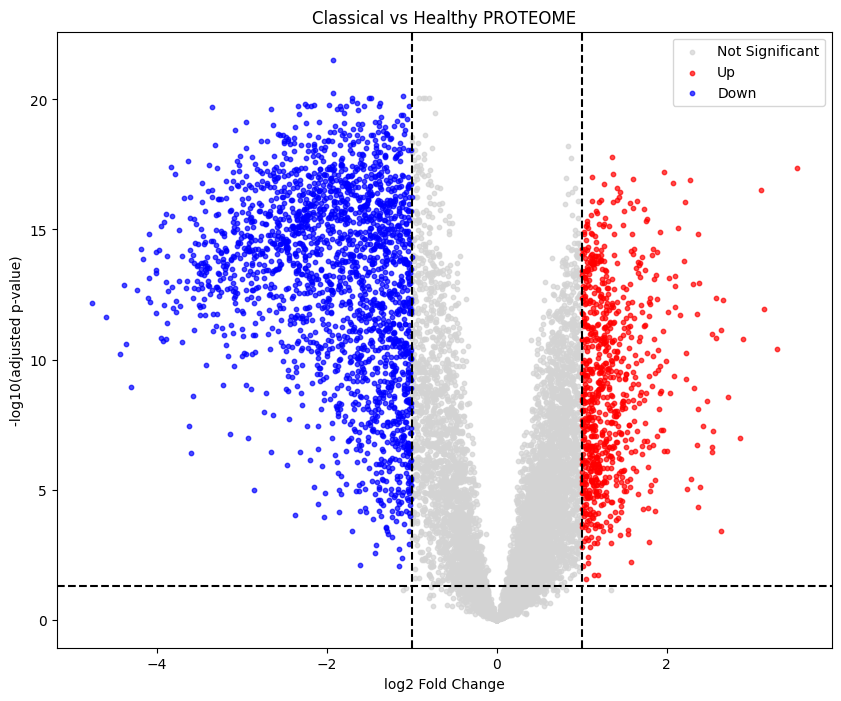

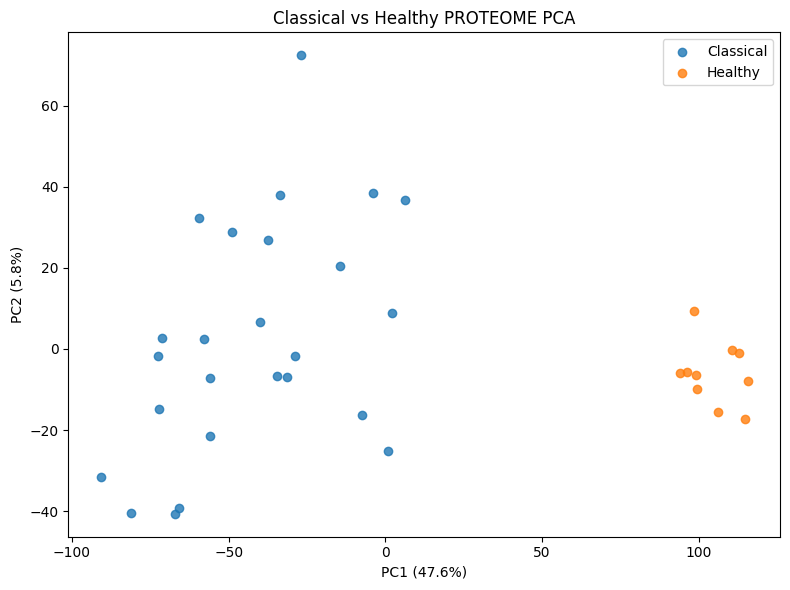

(           PC1        PC2      Group
 0   -59.552669  32.189599  Classical
 1   -28.794399  -1.787878  Classical
 2   -72.588895  -1.764403  Classical
 3   -65.805701 -39.216882  Classical
 4   -71.348954   2.739498  Classical
 5   -14.446899  20.430810  Classical
 6   -31.366065  -6.978730  Classical
 7   -55.868392  -7.238589  Classical
 8     0.976852 -25.175624  Classical
 9    -3.775550  38.548201  Classical
 10  -34.585562  -6.695683  Classical
 11  -37.455286  26.765085  Classical
 12    6.200805  36.699000  Classical
 13  -66.989707 -40.627708  Classical
 14  -26.946673  72.398298  Classical
 15  -55.981350 -21.351081  Classical
 16  -90.831319 -31.616877  Classical
 17  -33.590451  37.965136  Classical
 18  -49.033784  28.792226  Classical
 19  -72.091163 -14.744306  Classical
 20  -40.018338   6.611938  Classical
 21   -7.550468 -16.195233  Classical
 22  -57.860474   2.496691  Classical
 23  -81.171286 -40.489595  Classical
 24    2.154116   8.760814  Classical
 25  110.710

In [19]:
clas = diff.differential_expression(classical_expr,control_expr)
clas.to_csv('../data/interim/classical_pro_diff.csv')
diff.volcano_plot(clas,'Classical vs Healthy PROTEOME')
diff.pca_plot(classical_expr,control_expr,'Classical','Healthy','Classical vs Healthy PROTEOME PCA')

# IDH

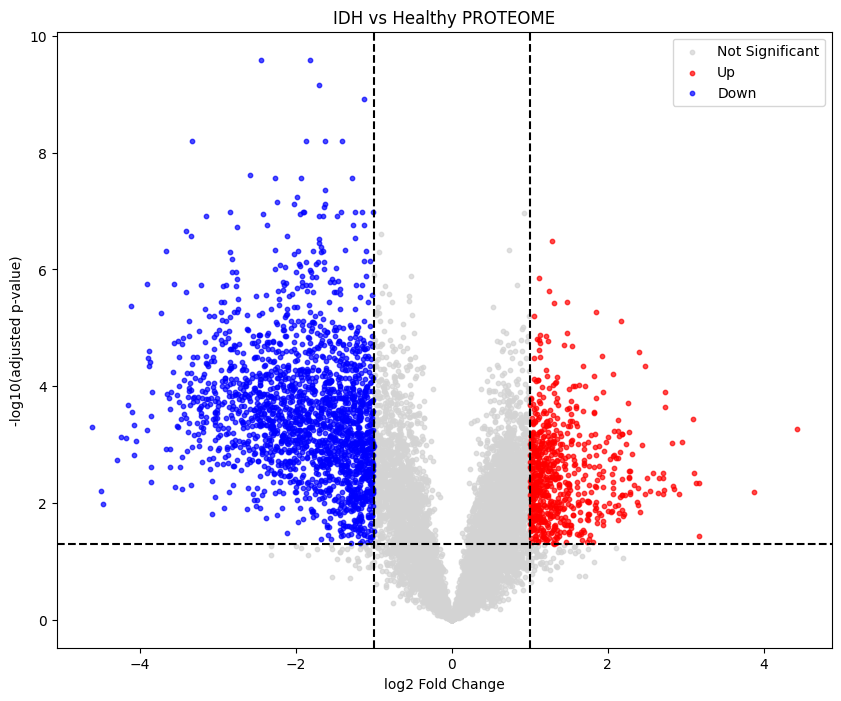

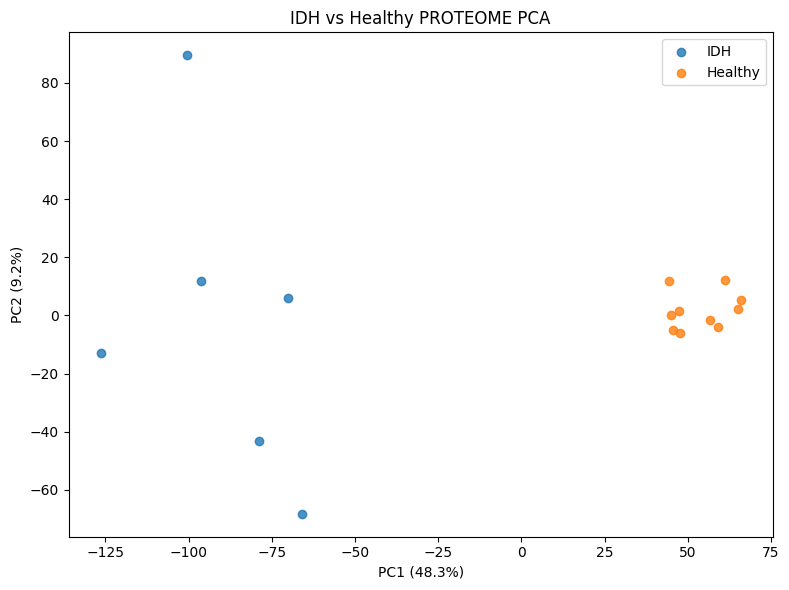

(           PC1        PC2    Group
 0   -70.098919   5.939678      IDH
 1  -126.426381 -12.770684      IDH
 2   -78.889734 -43.348369      IDH
 3   -65.964824 -68.279094      IDH
 4  -100.409799  89.541378      IDH
 5   -96.137755  11.966479      IDH
 6    59.198568  -3.958273  Healthy
 7    47.774806  -5.961805  Healthy
 8    65.849289   5.296788  Healthy
 9    61.277173  12.236446  Healthy
 10   47.255218   1.654949  Healthy
 11   44.959634   0.111518  Healthy
 12   45.566915  -4.856727  Healthy
 13   65.007560   2.260692  Healthy
 14   56.710432  -1.590690  Healthy
 15   44.327817  11.757714  Healthy,
 PCA(n_components=2))

In [20]:
idh = diff.differential_expression(idh_expr,control_expr)
idh.to_csv('../data/interim/idh_pro_diff.csv')
diff.volcano_plot(idh,'IDH vs Healthy PROTEOME')
diff.pca_plot(idh_expr,control_expr,'IDH','Healthy','IDH vs Healthy PROTEOME PCA')